Name: Bishnu Sharma  
Course: MSCS 634 - Data Mining  
Lab Assignment: Lab 1 - Data Visualization, Preprocessing, and Statistical Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("sales_data.csv")
df.head()

,Date,Product,Region,Sales,Profit
0,2024-01-01,Laptop,North,1200,200
1,2024-01-02,Phone,South,800,150
2,2024-01-03,Tablet,East,600,100
3,2024-01-04,Laptop,West,1500,300
4,2024-01-05,Phone,North,700,120


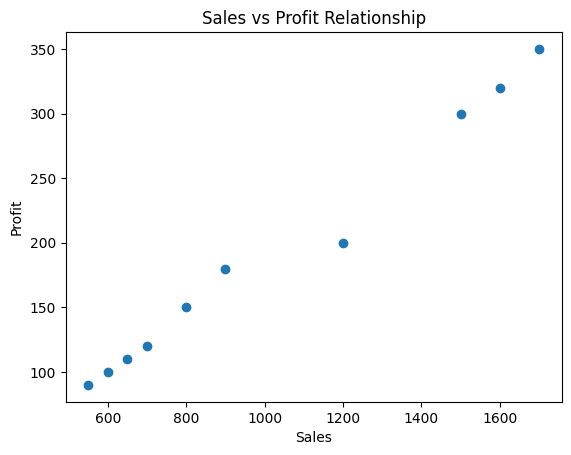

In [5]:
plt.scatter(df["Sales"], df["Profit"])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit Relationship")
plt.show()

Insight:
The scatter plot shows a positive relationship between sales and profit.
As sales increase, profit also tends to increase.

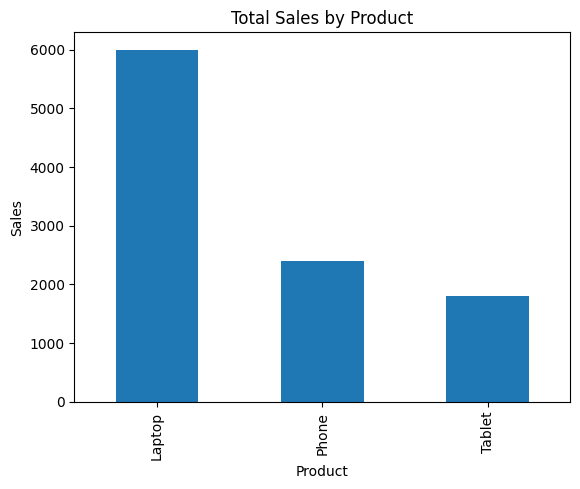

In [6]:
df.groupby("Product")["Sales"].sum().plot(kind="bar")
plt.title("Total Sales by Product")
plt.ylabel("Sales")
plt.xlabel("Product")
plt.show()

Insight:
The bar chart shows that laptops generate the highest total sales compared to phones and tablets.


In [7]:
df.isnull().sum()

,0
Date,0
Product,0
Region,0
Sales,0
Profit,0


In [8]:
df["Sales"].fillna(df["Sales"].mean(), inplace=True)

df.head()

/tmp/ipykernel_238/2839981286.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Sales"].fillna(df["Sales"].mean(), inplace=True)


,Date,Product,Region,Sales,Profit
0,2024-01-01,Laptop,North,1200,200
1,2024-01-02,Phone,South,800,150
2,2024-01-03,Tablet,East,600,100
3,2024-01-04,Laptop,West,1500,300
4,2024-01-05,Phone,North,700,120


In [9]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 662.5
Q3: 1425.0
IQR: 762.5
Lower Bound: -481.25
Upper Bound: 2568.75


In [10]:
outliers = df[(df["Sales"] < lower_bound) | (df["Sales"] > upper_bound)]

outliers

,Date,Product,Region,Sales,Profit


In [11]:
df_clean = df[(df["Sales"] >= lower_bound) & (df["Sales"] <= upper_bound)]

df_clean

,Date,Product,Region,Sales,Profit
0,2024-01-01,Laptop,North,1200,200
1,2024-01-02,Phone,South,800,150
2,2024-01-03,Tablet,East,600,100
3,2024-01-04,Laptop,West,1500,300
4,2024-01-05,Phone,North,700,120
5,2024-01-06,Tablet,South,650,110
6,2024-01-07,Laptop,East,1700,350
7,2024-01-08,Phone,West,900,180
8,2024-01-09,Tablet,North,550,90
9,2024-01-10,Laptop,South,1600,320


In [12]:
df_sample = df.sample(frac=0.5)

df_sample

,Date,Product,Region,Sales,Profit
7,2024-01-08,Phone,West,900,180
2,2024-01-03,Tablet,East,600,100
0,2024-01-01,Laptop,North,1200,200
3,2024-01-04,Laptop,West,1500,300
8,2024-01-09,Tablet,North,550,90


In [13]:
df_reduced = df.drop(columns=["Date"])

df_reduced.head()

,Product,Region,Sales,Profit
0,Laptop,North,1200,200
1,Phone,South,800,150
2,Tablet,East,600,100
3,Laptop,West,1500,300
4,Phone,North,700,120


In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["Sales_scaled"] = scaler.fit_transform(df[["Sales"]])

df.head()

,Date,Product,Region,Sales,Profit,Sales_scaled
0,2024-01-01,Laptop,North,1200,200,0.565217
1,2024-01-02,Phone,South,800,150,0.217391
2,2024-01-03,Tablet,East,600,100,0.043478
3,2024-01-04,Laptop,West,1500,300,0.826087
4,2024-01-05,Phone,North,700,120,0.130435


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          10 non-null     object 
 1   Product       10 non-null     object 
 2   Region        10 non-null     object 
 3   Sales         10 non-null     int64  
 4   Profit        10 non-null     int64  
 5   Sales_scaled  10 non-null     float64
dtypes: float64(1), int64(2), object(3)
memory usage: 612.0+ bytes


In [16]:
df.describe()

,Sales,Profit,Sales_scaled
count,10.000000,10.000000,10.000000
mean,1020.000000,192.000000,0.408696
std,442.342251,97.616028,0.384645
min,550.000000,90.000000,0.000000
25%,662.500000,112.500000,0.097826
50%,850.000000,165.000000,0.260870
75%,1425.000000,275.000000,0.760870
max,1700.000000,350.000000,1.000000


In [17]:
print("Minimum:", df["Sales"].min())
print("Maximum:", df["Sales"].max())
print("Mean:", df["Sales"].mean())
print("Median:", df["Sales"].median())
print("Mode:", df["Sales"].mode()[0])

Minimum: 550
Maximum: 1700
Mean: 1020.0
Median: 850.0
Mode: 550


In [18]:
range_value = df["Sales"].max() - df["Sales"].min()
variance = df["Sales"].var()
std_dev = df["Sales"].std()

quartiles = df["Sales"].quantile([0.25,0.5,0.75])
iqr = quartiles[0.75] - quartiles[0.25]

print("Range:", range_value)
print("Variance:", variance)
print("Standard Deviation:", std_dev)
print("Quartiles:", quartiles)
print("IQR:", iqr)

Range: 1150
Variance: 195666.66666666666
Standard Deviation: 442.3422506008969
Quartiles: 0.25     662.5
0.50     850.0
0.75    1425.0
Name: Sales, dtype: float64
IQR: 762.5


In [19]:
df.corr(numeric_only=True)

,Sales,Profit,Sales_scaled
Sales,1.000000,0.992236,1.000000
Profit,0.992236,1.000000,0.992236
Sales_scaled,1.000000,0.992236,1.000000


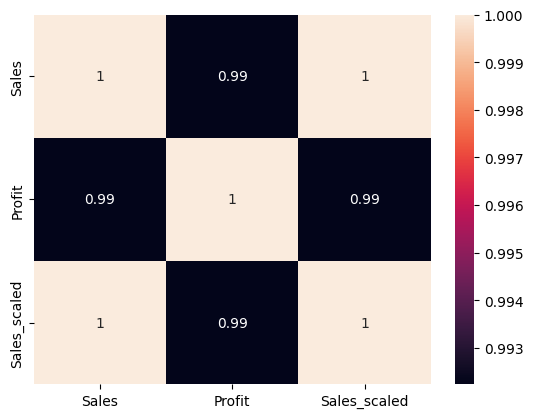

In [20]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()